In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
import plotly.graph_objects as go

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
import plotly.graph_objects as go

from lin_reg_utils import *

In [10]:
# Load data
cities_df = pd.read_csv('../data/cities_with_all_data.csv')
cols = ['Nazev_obce_prijmy', 'Nejblizsi_nemocnice', 'Vzdalenost_km', 'Lat_x', 'Lon_x', 'DPFO', 'Total']
cities_df = cities_df[cols].dropna()

# drop cities with extreme DPFO values
cities_df['DPFO_per_capita'] = cities_df['DPFO'].copy()
cities_df['DPFO_per_capita'] = cities_df['DPFO'] / cities_df['Total']
#cities_df = cities_df[(cities_df['Vzdalenost_km'] > cities_df['Vzdalenost_km'].quantile(0.01)) & (cities_df['Vzdalenost_km'] < cities_df['Vzdalenost_km'].quantile(0.99))]
cities_df = cities_df[(cities_df['DPFO_per_capita'] > cities_df['DPFO_per_capita'].quantile(0.01)) & (cities_df['DPFO_per_capita'] < cities_df['DPFO_per_capita'].quantile(0.99))]

#print number of rows after dropping
print(f"Number of rows after dropping extreme DPFO values: {len(cities_df)}")


Number of rows after dropping extreme DPFO values: 6131


                            OLS Regression Results                            
Dep. Variable:          Vzdalenost_km   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     117.2
Date:                Sat, 13 Dec 2025   Prob (F-statistic):           4.47e-27
Time:                        11:22:08   Log-Likelihood:                -20038.
No. Observations:                6131   AIC:                         4.008e+04
Df Residuals:                    6129   BIC:                         4.009e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.9407      0.641     

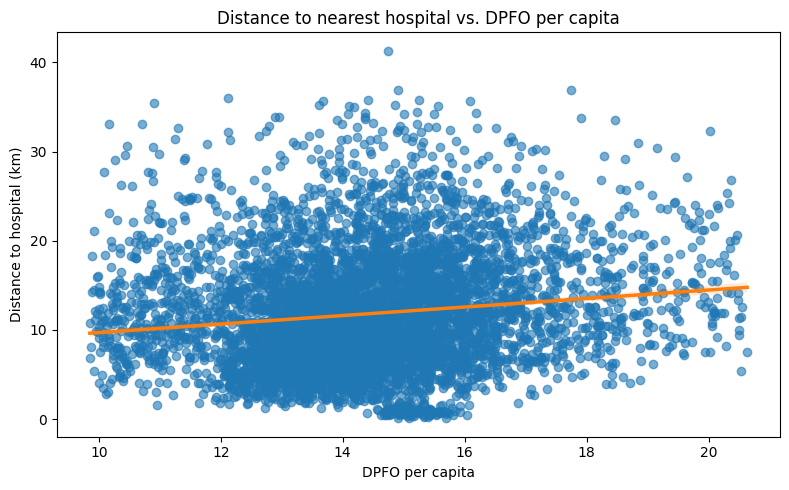

TEST LINEARITY


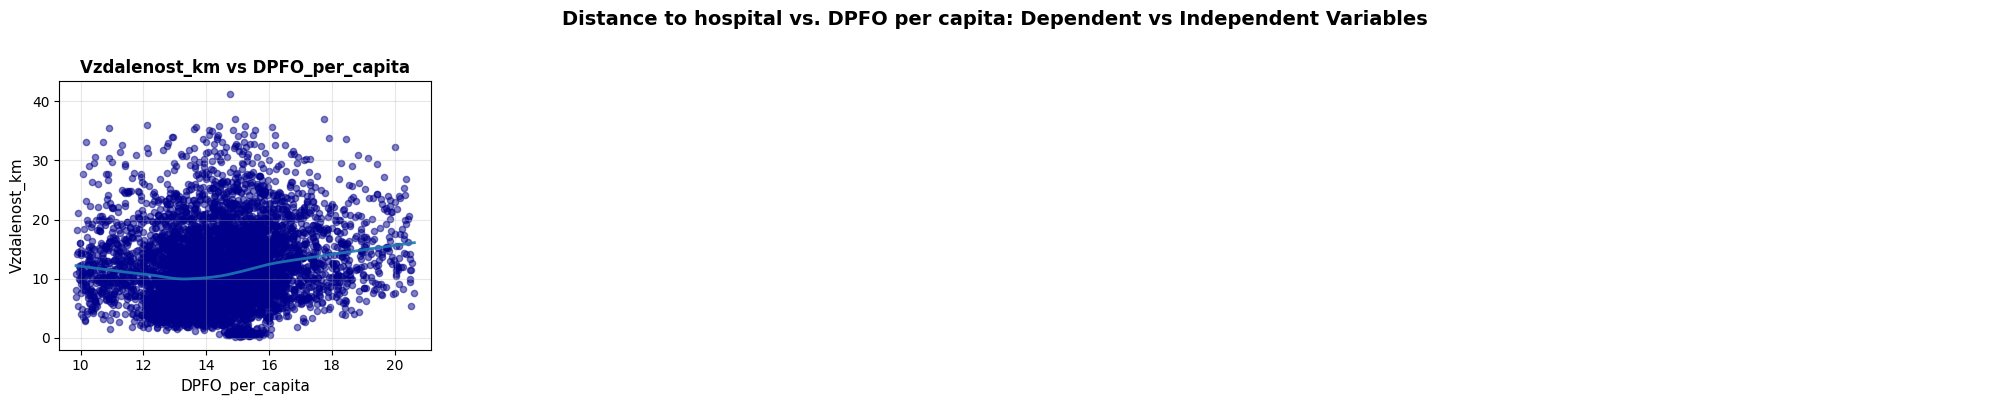

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



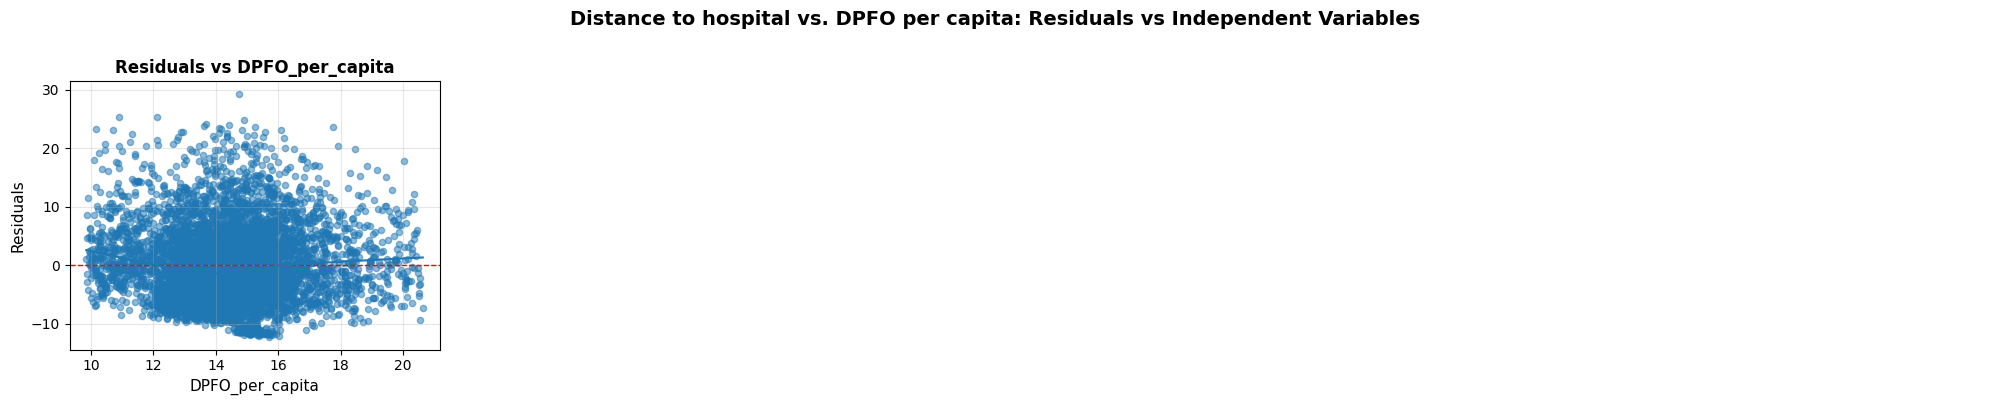

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Distance to hospital vs. DPFO per capita: 0.9668 (LM stat=0.068)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Distance to hospital vs. DPFO per capita: 1.392
Ljung–Box test results for Distance to hospital vs. DPFO per capita (lags [10, 20, 40]):
         lb_stat  lb_pvalue
10   4233.376009        0.0
20   7162.948305        0.0
40  10596.296973        0.0


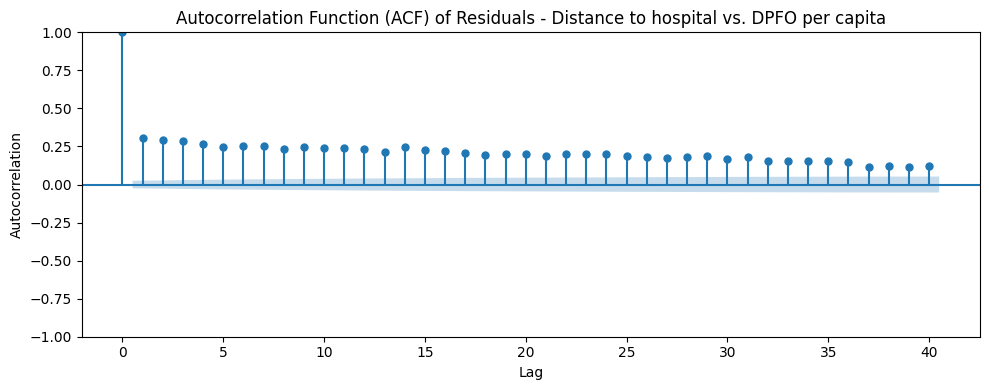

------------------------------------------------
TEST NORMALITY OF ERRORS


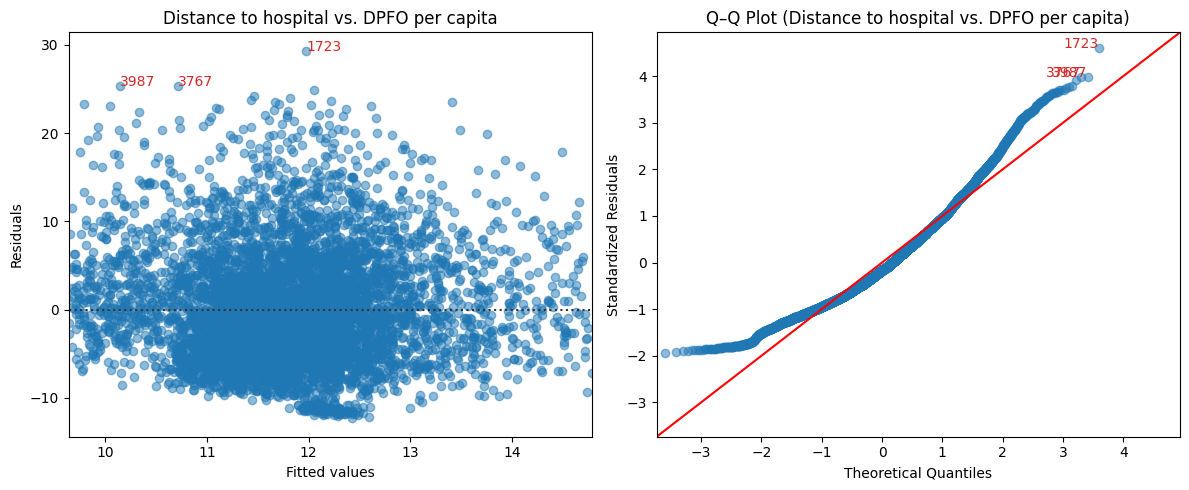

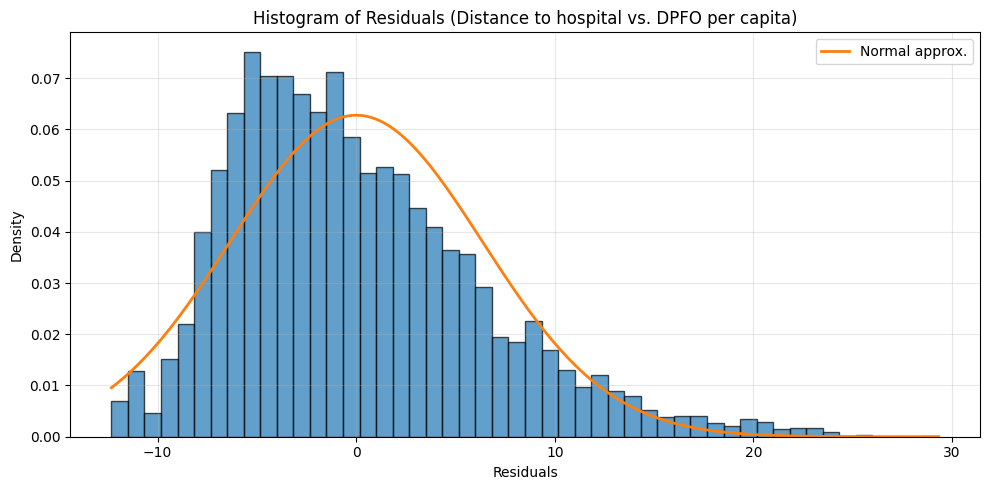

Shapiro–Wilk test for Distance to hospital vs. DPFO per capita: W=0.9543, p-value=4.397e-40
------------------------------------------------
TEST MULTICOLLINEARITY


/usr/lib/python3/dist-packages/scipy/stats/_morestats.py:1761: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


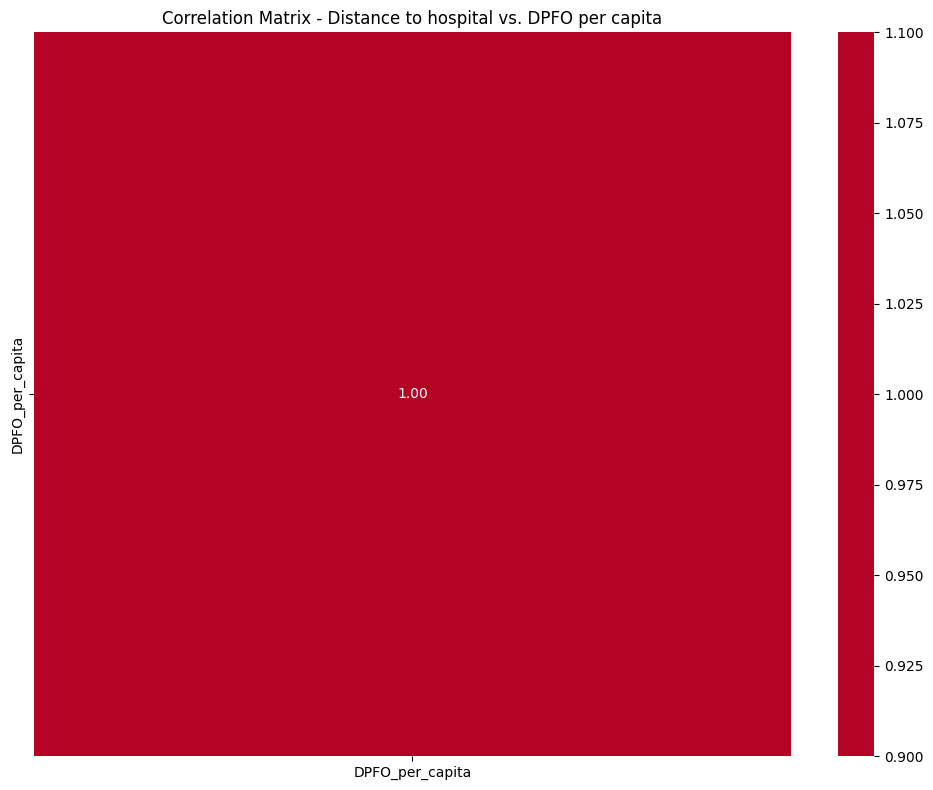

Variance Inflation Factor (VIF):
          Features  VIF Factor
1  DPFO_per_capita        1.00
0            const       62.24
------------------------------------------------


In [4]:
X = sm.add_constant(cities_df[['DPFO_per_capita']])
y = cities_df['Vzdalenost_km']
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

plt.figure(figsize=(8, 5))
sns.regplot(
    x='DPFO_per_capita',
    y='Vzdalenost_km',
    data=cities_df,
    scatter_kws={'alpha': 0.6, 'color': 'tab:blue'},
    line_kws={'color': 'tab:orange', 'linewidth': 2.5}
)
plt.title('Distance to nearest hospital vs. DPFO per capita')
plt.xlabel('DPFO per capita')
plt.ylabel('Distance to hospital (km)')
plt.tight_layout()
plt.show()

perform_all_tests(
    ols_model,
    data_=cities_df[['DPFO_per_capita', 'Vzdalenost_km']],
    features=['DPFO_per_capita'],
    model_name="Distance to hospital vs. DPFO per capita",
    y_col="Vzdalenost_km"
)

Na základě lineární regrese můžeme říct, že mezi DPFO na obyvatele a vzdáleností k nejbližší nemocnici existuje statisticky významný, ale velmi slabý vztah. Koeficient u DPFO_per_capita je přibližně 0,48 km a jeho p‑hodnota je < 0,001, což znamená, že s rostoucím DPFO na obyvatele mají obce tendenci být o něco dál od nemocnice – každé zvýšení DPFO o jednu jednotku je spojeno s průměrným nárůstem vzdálenosti zhruba o půl kilometru. Intercept kolem 4,9 km představuje modelovanou vzdálenost v hypotetické obci s nulovým DPFO na obyvatele, sám o sobě ale nemá zásadní interpretační význam.

Z hlediska vysvětlující síly modelu je však tento vztah velmi slabý – hodnota R² ≈ 0,019 ukazuje, že DPFO na obyvatele vysvětluje jen asi 1,9 % variability ve vzdálenosti k nemocnici. Drtivou většinu rozdílů mezi obcemi tedy určují jiné faktory (geografie, hustota osídlení, síť nemocnic atd.). Testy normality (Omnibus, Jarque–Bera) navíc naznačují, že rezidua nejsou ideálně normální, takže pro formálnější inferenci by bylo vhodné použít robustnější postupy – nic z toho ale nemění závěr, že vztah je sice statisticky prokazatelný, ale prakticky spíše slabý.

Reziduální diagnostika ukazuje, že lineární tvar a homoskedasticita jsou v zásadě v pořádku, ale předpoklady o nezávislosti a normalitě chyb jsou porušené. Breusch–Paganův test má p‑hodnotu ≈ 0,97, takže nevidíme systematický vztah mezi velikostí reziduí a predikovanými hodnotami – model tedy netrpí výraznou heteroskedasticitou. LOWESS křivky a grafy reziduí proti fitted hodnotám nenasvědčují silné nelinearitě; jednoduchá lineární závislost je tedy jako první aproximace přijatelná.

Naopak Shapiro–Wilkův test, histogram reziduí a Q–Q graf jasně ukazují odchylku od normálního rozdělení (asymetrie a těžší pravý ocas) a Ljung–Box testy indikují autokorelaci reziduí napříč řadou pozorování. Spolu s nízkým Durbin–Watsonovým statistikem (~1,39) to znamená, že chyby nejsou nezávislé. V praxi to snižuje spolehlivost klasických OLS intervalů spolehlivosti a testů hypotéz; pokud bychom chtěli dělat formální inferenci, bylo by vhodné použít robustní (např. heteroskedasticity‑/autokorelace‑konzistentní) odhady směrodatných chyb nebo robustní/nelinerání modely. Ani tyto problémy ale nemění hlavní závěr: vztah mezi DPFO na obyvatele a vzdáleností k nemocnici je sice statisticky prokazatelný, ale vysvětluje jen zanedbatelnou část variability v datech.

/tmp/ipykernel_7325/2733484348.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['DPFO_per_capita_sq'] = X['DPFO_per_capita'] ** 2


                            OLS Regression Results                            
Dep. Variable:          Vzdalenost_km   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     97.32
Date:                Sat, 13 Dec 2025   Prob (F-statistic):           2.46e-42
Time:                        11:22:12   Log-Likelihood:                -20000.
No. Observations:                6131   AIC:                         4.001e+04
Df Residuals:                    6128   BIC:                         4.003e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 32.4138      3

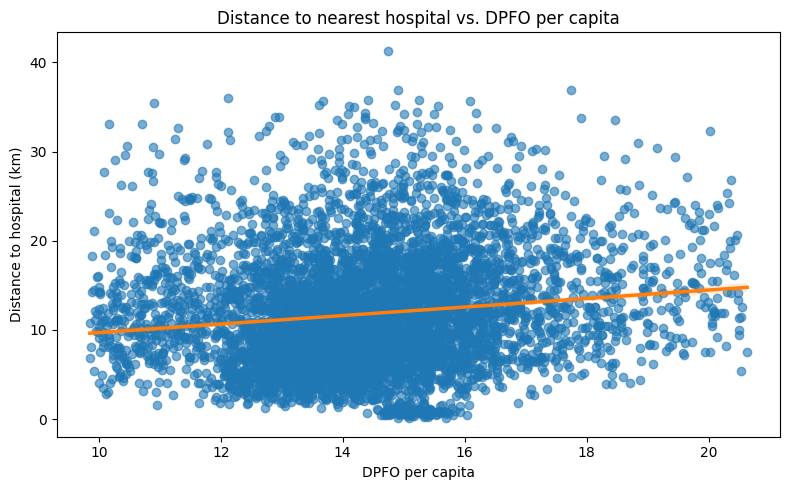

TEST LINEARITY


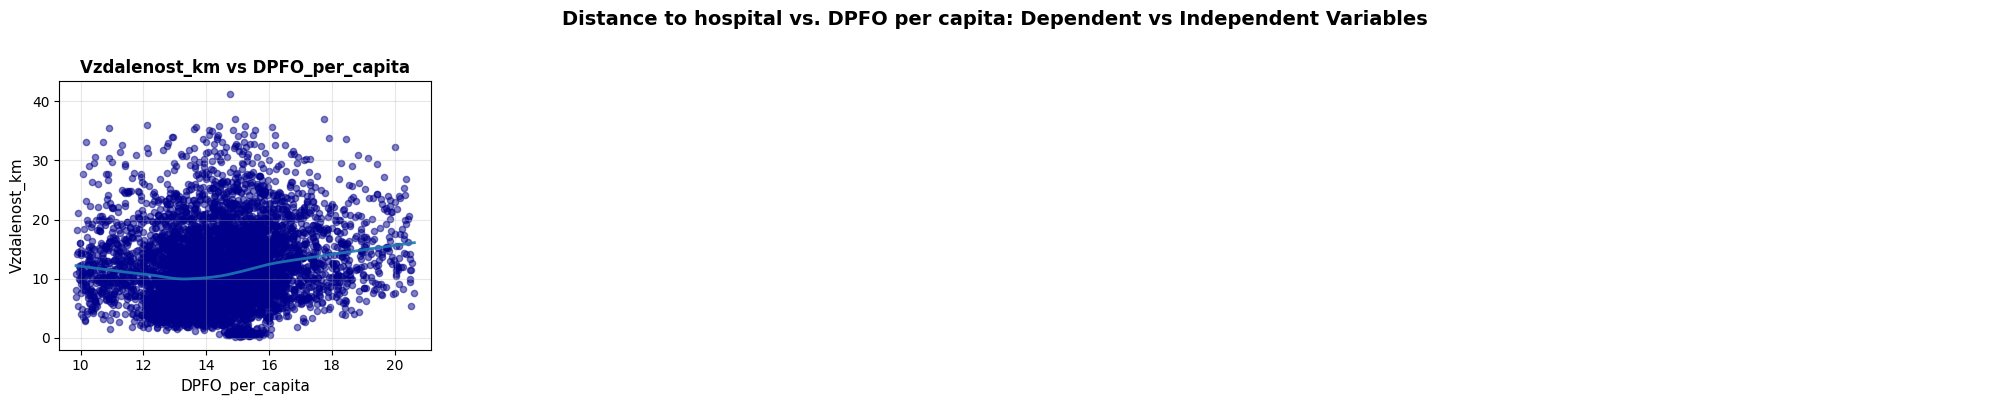

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



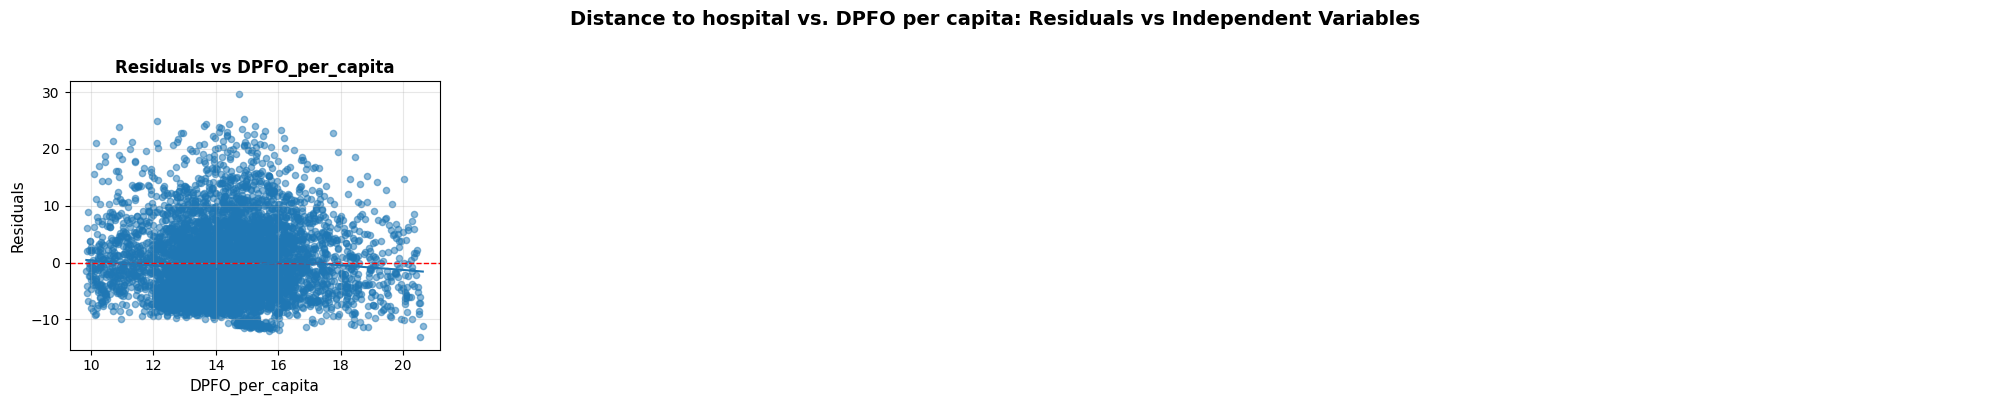

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Distance to hospital vs. DPFO per capita: 0.3669 (LM stat=3.165)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Distance to hospital vs. DPFO per capita: 1.398
Ljung–Box test results for Distance to hospital vs. DPFO per capita (lags [10, 20, 40]):
         lb_stat  lb_pvalue
10   4172.276586        0.0
20   7061.402325        0.0
40  10438.597898        0.0


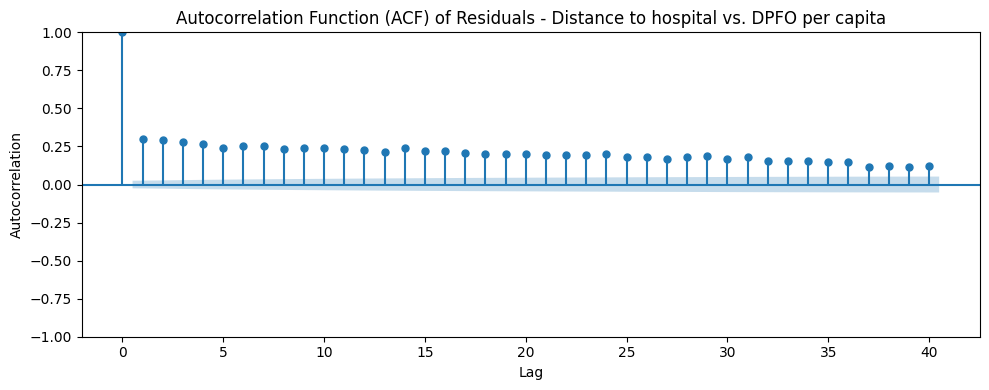

------------------------------------------------
TEST NORMALITY OF ERRORS


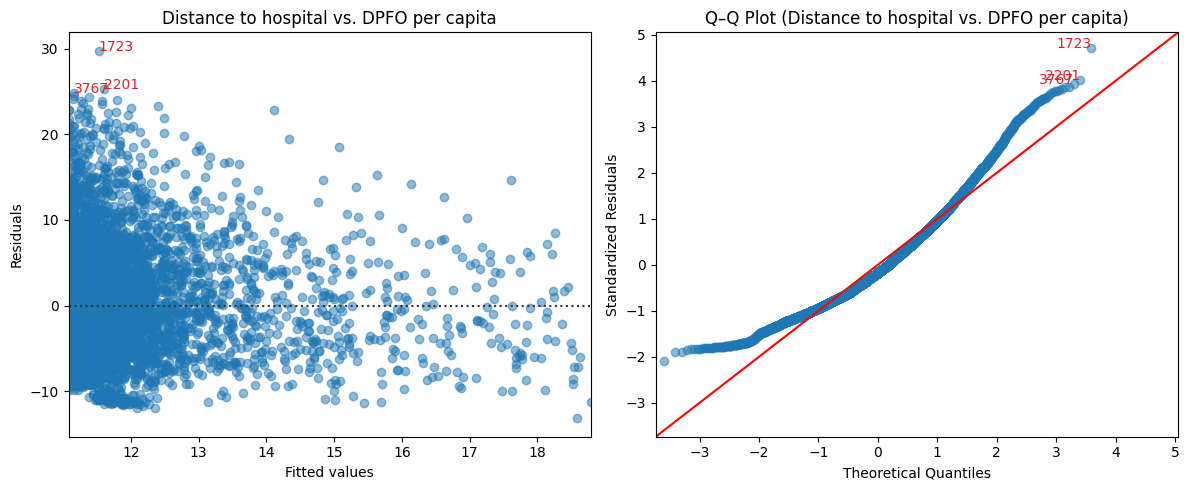

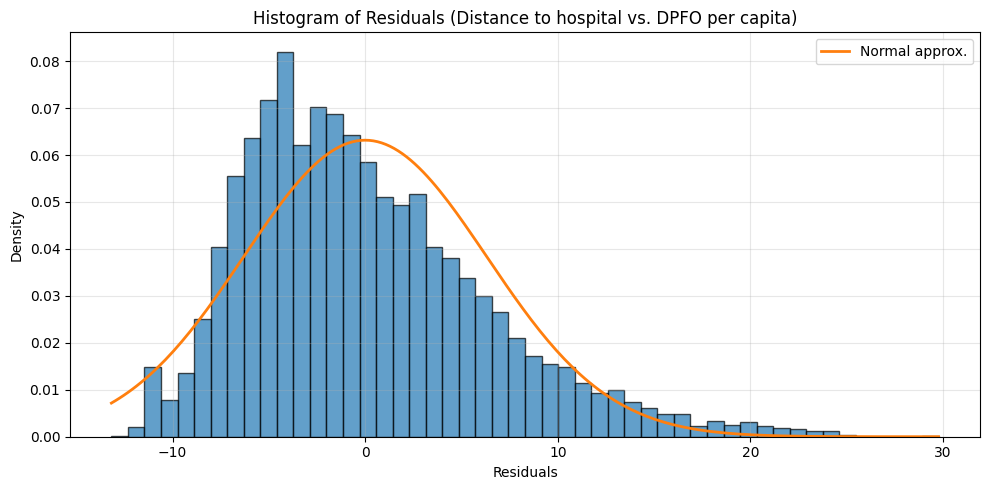

Shapiro–Wilk test for Distance to hospital vs. DPFO per capita: W=0.9521, p-value=8.085e-41
------------------------------------------------
TEST MULTICOLLINEARITY


/usr/lib/python3/dist-packages/scipy/stats/_morestats.py:1761: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


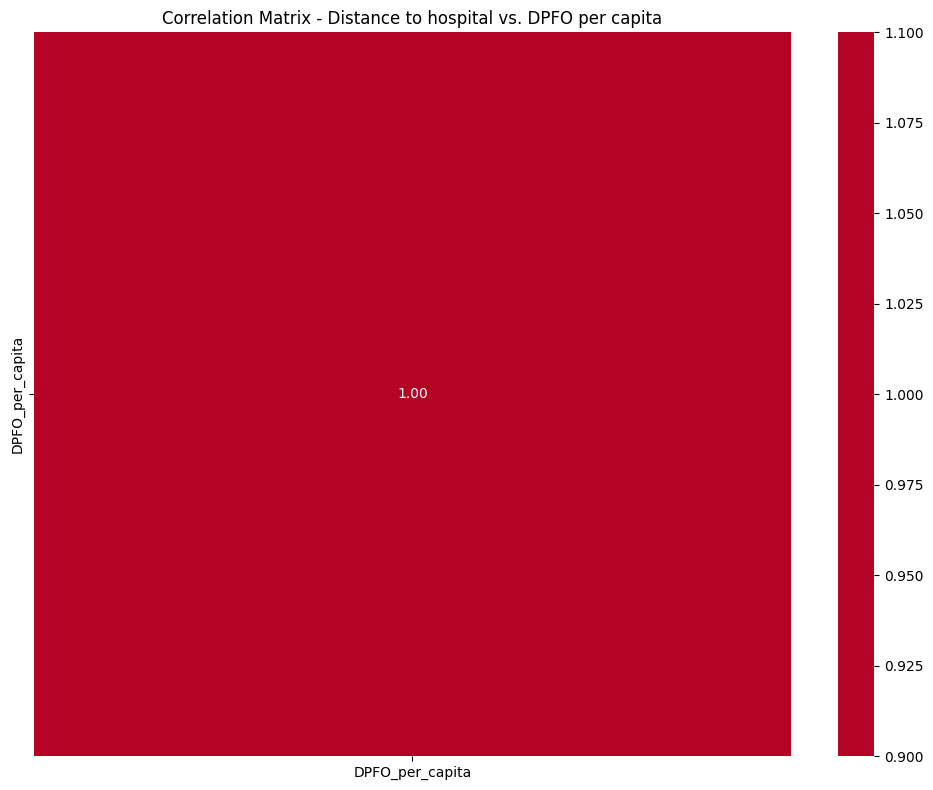

Variance Inflation Factor (VIF):
             Features  VIF Factor
1     DPFO_per_capita       99.52
2  DPFO_per_capita_sq       99.52
0               const     1588.00
------------------------------------------------


In [5]:
# with no trimming of the data

cities_df = pd.read_csv('../data/cities_with_all_data.csv')
cols = ['Nazev_obce_prijmy', 'Nejblizsi_nemocnice', 'Vzdalenost_km', 'Lat_x', 'Lon_x', 'DPFO', 'Total']
cities_df = cities_df[cols].dropna()    
cities_df['DPFO_per_capita'] = cities_df['DPFO'].copy()
cities_df['DPFO_per_capita'] = cities_df['DPFO'] / cities_df['Total']
# drop cities with extreme DPFO values
cities_df = cities_df[(cities_df['DPFO_per_capita'] > cities_df['DPFO_per_capita'].quantile(0.01)) & (cities_df['DPFO_per_capita'] < cities_df['DPFO_per_capita'].quantile(0.99))]


#X = sm.add_constant(cities_df[['DPFO_per_capita']])
#make X quadratic
X = cities_df[['DPFO_per_capita']]
X['DPFO_per_capita_sq'] = X['DPFO_per_capita'] ** 2
X = sm.add_constant(X)
y = cities_df['Vzdalenost_km']
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

plt.figure(figsize=(8, 5))
sns.regplot(
    x='DPFO_per_capita',
    y='Vzdalenost_km',
    data=cities_df,
    scatter_kws={'alpha': 0.6, 'color': 'tab:blue'},
    line_kws={'color': 'tab:orange', 'linewidth': 2.5}
)
plt.title('Distance to nearest hospital vs. DPFO per capita')
plt.xlabel('DPFO per capita')
plt.ylabel('Distance to hospital (km)')
plt.tight_layout()
plt.show()

perform_all_tests(
    ols_model,
    data_=cities_df[['DPFO_per_capita', 'Vzdalenost_km']],
    features=['DPFO_per_capita'],
    model_name="Distance to hospital vs. DPFO per capita",
    y_col="Vzdalenost_km"
)


# Pokud o přidání víc variables

                            OLS Regression Results                            
Dep. Variable:          Vzdalenost_km   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     201.4
Date:                Sat, 13 Dec 2025   Prob (F-statistic):          5.73e-124
Time:                        11:34:48   Log-Likelihood:                -17424.
No. Observations:                5531   AIC:                         3.486e+04
Df Residuals:                    5527   BIC:                         3.488e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.9694      0.666     

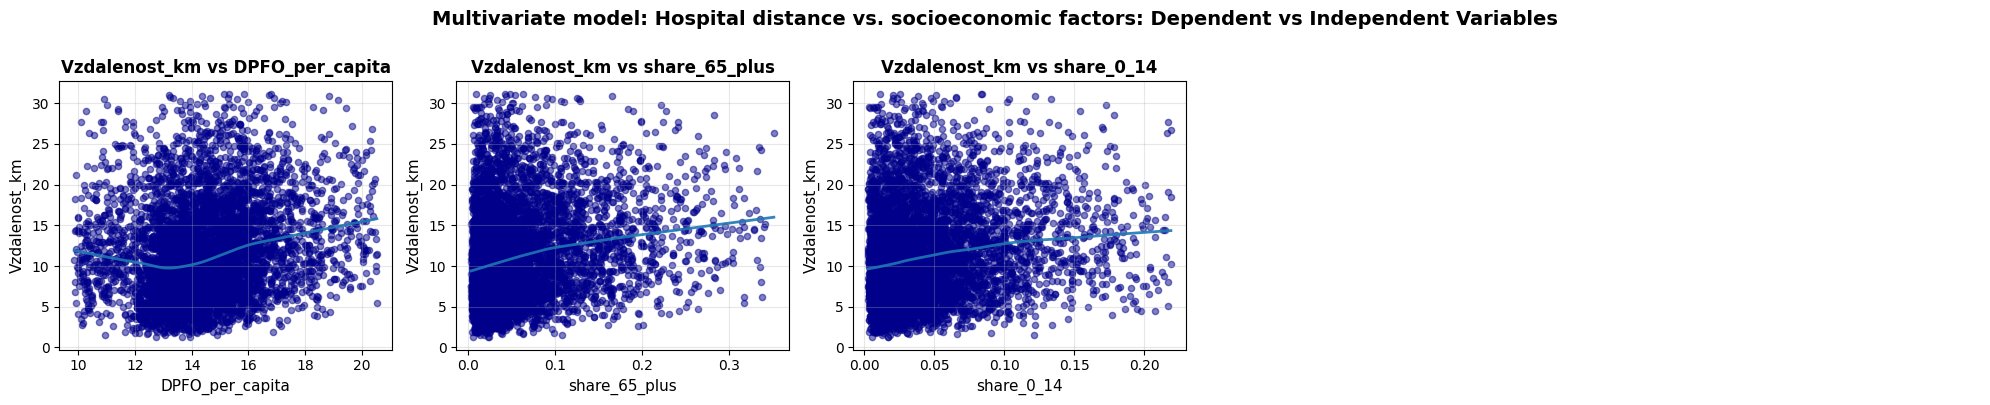

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



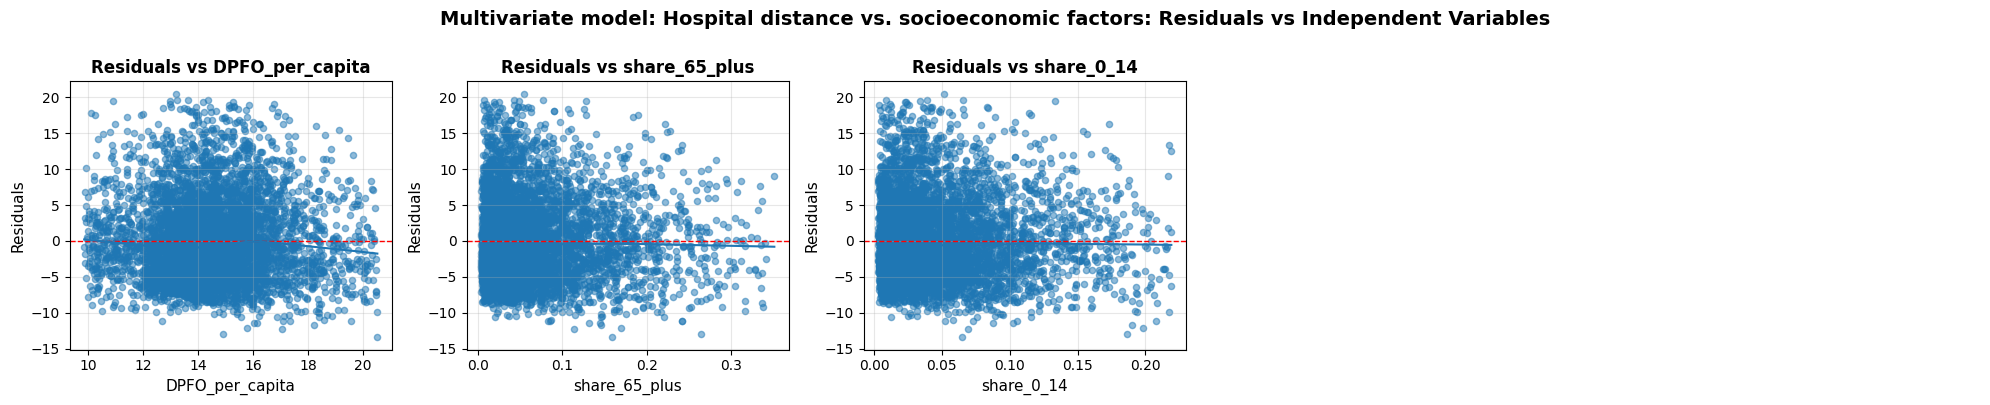

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Multivariate model: Hospital distance vs. socioeconomic factors: 0.08178 (LM stat=8.282)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Multivariate model: Hospital distance vs. socioeconomic factors: 1.452
Ljung–Box test results for Multivariate model: Hospital distance vs. socioeconomic factors (lags [10, 20, 40]):
        lb_stat  lb_pvalue
10  3066.633196        0.0
20  5086.568332        0.0
40  6870.296505        0.0


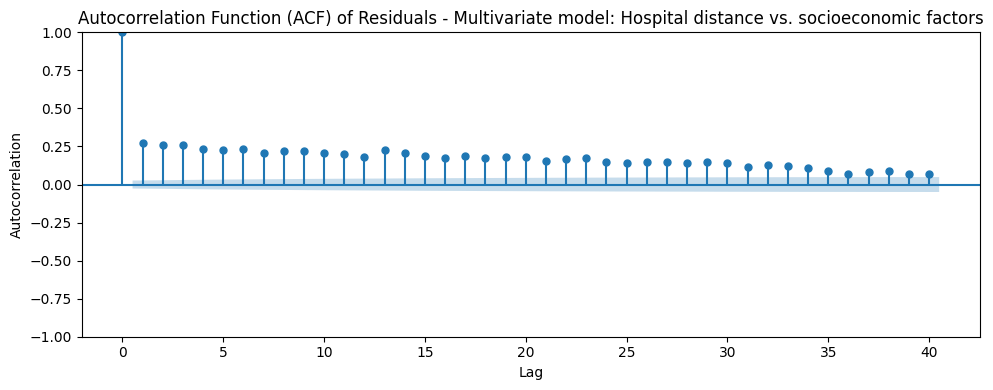

------------------------------------------------
TEST NORMALITY OF ERRORS


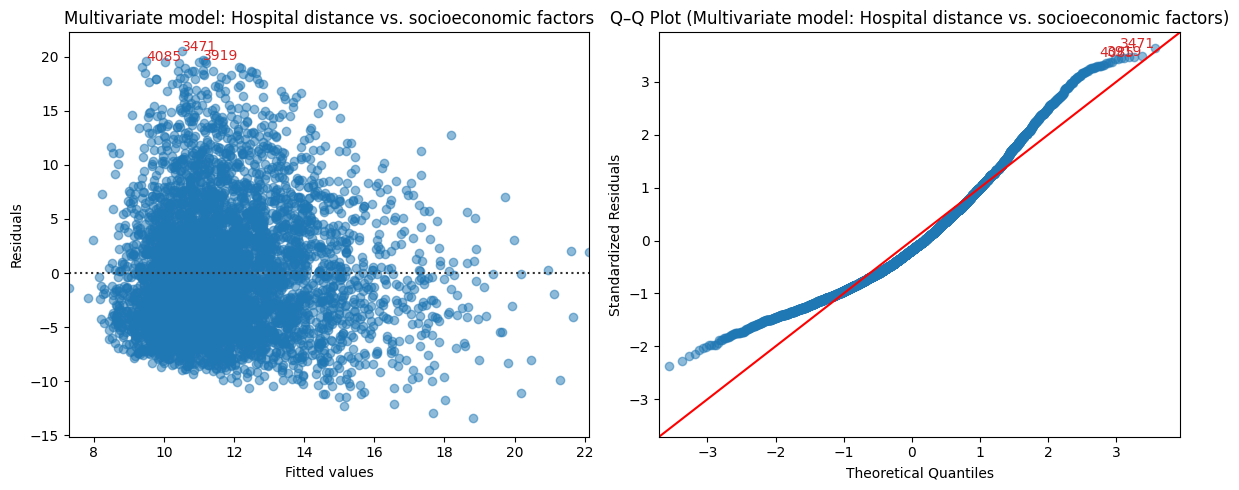

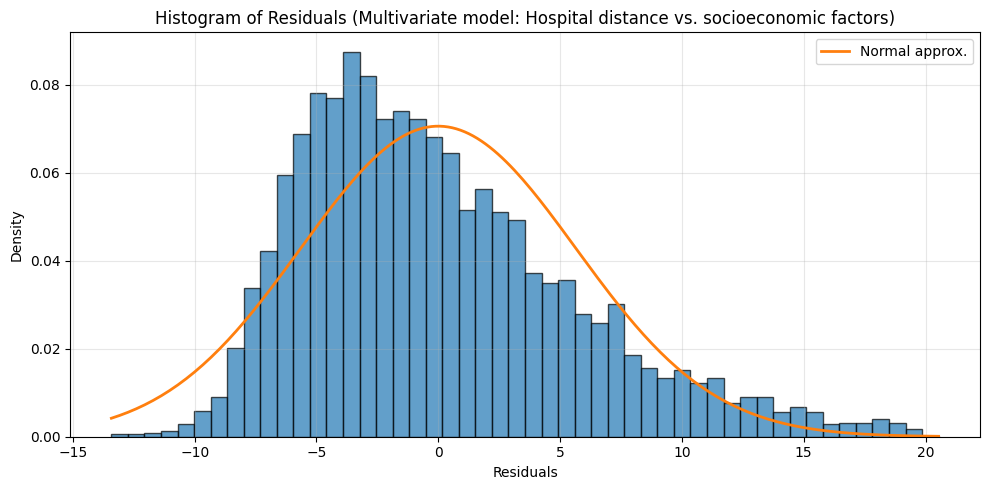

Shapiro–Wilk test for Multivariate model: Hospital distance vs. socioeconomic factors: W=0.9522, p-value=3.703e-39
------------------------------------------------
TEST MULTICOLLINEARITY


/usr/lib/python3/dist-packages/scipy/stats/_morestats.py:1761: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


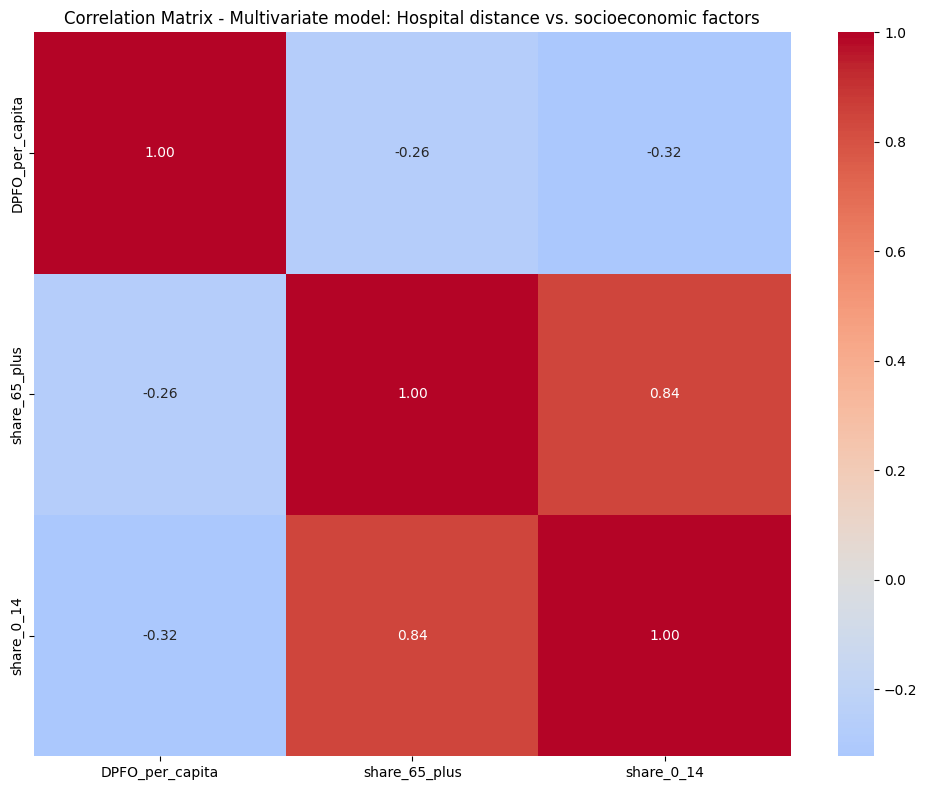

Variance Inflation Factor (VIF):
          Features  VIF Factor
1  DPFO_per_capita        1.12
2    share_65_plus        3.42
3       share_0_14        3.56
0            const       76.95
------------------------------------------------


In [7]:
# Load data for multivariate model
cities_df = pd.read_csv('../data/cities_with_all_data.csv')

upper_quantile = 0.99
lower_quantile = 0.01
cities_df['DPFO_per_capita'] = cities_df['DPFO'].copy()
cities_df['DPFO_per_capita'] = cities_df['DPFO'] / cities_df['Total']
cities_df = cities_df[(cities_df['Vzdalenost_km'] > cities_df['Vzdalenost_km'].quantile(lower_quantile)) & (cities_df['Vzdalenost_km'] < cities_df['Vzdalenost_km'].quantile(upper_quantile))]
cities_df = cities_df[(cities_df['DPFO_per_capita'] > cities_df['DPFO_per_capita'].quantile(lower_quantile)) & (cities_df['DPFO_per_capita'] < cities_df['DPFO_per_capita'].quantile(upper_quantile))]
cities_df = cities_df[(cities_df['Total'] > cities_df['Total'].quantile(lower_quantile)) & (cities_df['Total'] < cities_df['Total'].quantile(upper_quantile))]
cities_df = cities_df[(cities_df['DPFO'] > cities_df['DPFO'].quantile(lower_quantile)) & (cities_df['DPFO'] < cities_df['DPFO'].quantile(upper_quantile))]

cols = [
    'Nazev_obce_prijmy',
    'Nejblizsi_nemocnice',
    'Vzdalenost_km',
    'Lat_x', 'Lon_x',
    'DPFO', 'Total',
    'age_65_plus_total', 'age_0_14_total'
]
all_df = cities_df[cols].dropna()

# Převod na číselné typy (pokud jsou teď stringy)
num_cols = ['DPFO', 'Total', 'age_65_plus_total', 'age_0_14_total', 'Vzdalenost_km']
for c in num_cols:
    all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

all_df = all_df.dropna(subset=num_cols)

# Vytvoření dalších ukazatelů
all_df['DPFO_per_capita'] = all_df['DPFO'] / all_df['Total']
#all_df['DPFO_per_capita'] = all_df['DPFO_per_capita']**2
all_df['share_65_plus'] = all_df['age_65_plus_total'] / all_df['Total']
all_df['share_0_14'] = all_df['age_0_14_total'] / all_df['Total']

all_df = all_df[(all_df['share_65_plus'] > all_df['share_65_plus'].quantile(lower_quantile)) & (all_df['share_65_plus'] < all_df['share_65_plus'].quantile(upper_quantile))]
all_df = all_df[(all_df['share_0_14'] > all_df['share_0_14'].quantile(lower_quantile)) & (all_df['share_0_14'] < all_df['share_0_14'].quantile(upper_quantile))]

# Odstranění extrémů a NA
model_df = all_df[
    ['Vzdalenost_km', 'DPFO_per_capita', 'share_65_plus', 'share_0_14']
].dropna()

#model_df['log_Total'] = np.log(model_df['Total'])

#model_df = pd.get_dummies(model_df, columns=['Kraj'], drop_first=True)

# ...po vytvoření model_df a get_dummies...

y = model_df['Vzdalenost_km']
X = model_df.drop(columns=['Vzdalenost_km'])

# převod všeho na čísla + změna bool -> float
for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(float)
    else:
        X[col] = pd.to_numeric(X[col], errors='coerce')

y = pd.to_numeric(y, errors='coerce')


valid = X.notna().all(axis=1) & y.notna()
X = X[valid]
y = y[valid]

X = sm.add_constant(X)
multi_model = sm.OLS(y, X).fit()
print(multi_model.summary())


# all predictors *except* the constant
feature_cols = [col for col in X.columns if col != 'const']

perform_all_tests(
    multi_model,
    data_=model_df,             # original data with Vzdalenost_km + predictors
    features=feature_cols,      # no 'const' here
    model_name="Multivariate model: Hospital distance vs. socioeconomic factors",
    y_col="Vzdalenost_km"
)